In [1]:
import torch
import matplotlib.pyplot as plt
from graphs import plot_loss_flattening
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
from models.efficientnet import run

path = "./normalized_images"

num_epochs = 5
lr = 1e-4
threshold = 0.6

model, train_losses, eval_losses, eval_preds, eval_labels, test_preds, test_labels = run(path, device, num_epochs=num_epochs, lr=lr, test=True, threshold=threshold)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/madsfjeldberg/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 44.1MB/s]


-- EfficientNet_B0 | Epochs: 5 | LR: 0.0001
Epoch 1/5 - Train Loss: 0.2982, Eval Loss: 0.2186
Epoch 2/5 - Train Loss: 0.2177, Eval Loss: 0.2184
Epoch 3/5 - Train Loss: 0.2094, Eval Loss: 0.2194
Epoch 4/5 - Train Loss: 0.2030, Eval Loss: 0.2155
Epoch 5/5 - Train Loss: 0.2005, Eval Loss: 0.2175
Training time: 731.199s
Train:
               precision    recall  f1-score   support

      NORMAL       1.00      0.84      0.91      7263
   PNEUMONIA       0.70      0.99      0.82      2737

    accuracy                           0.88     10000
   macro avg       0.85      0.92      0.87     10000
weighted avg       0.91      0.88      0.89     10000

Eval:
               precision    recall  f1-score   support

      NORMAL       0.98      0.83      0.90       900
   PNEUMONIA       0.78      0.97      0.86       570

    accuracy                           0.88      1470
   macro avg       0.88      0.90      0.88      1470
weighted avg       0.90      0.88      0.88      1470

Test:
       

In [4]:
from sklearn.metrics import classification_report                                                  
for threshold in [0.5, 0.55, 0.6, 0.65, 0.7]:                                                                        
    print(f"\nThreshold: {threshold}")                                                                               
    print(classification_report(                                                                                     
        test_labels.astype(int),                                                                                     
        (test_preds >= threshold).astype(int),                                                                       
        target_names=["NORMAL", "PNEUMONIA"]                                                                         
    ))  


Threshold: 0.5
              precision    recall  f1-score   support

      NORMAL       1.00      0.82      0.90       925
   PNEUMONIA       0.78      1.00      0.88       580

    accuracy                           0.89      1505
   macro avg       0.89      0.91      0.89      1505
weighted avg       0.91      0.89      0.89      1505


Threshold: 0.55
              precision    recall  f1-score   support

      NORMAL       1.00      0.82      0.90       925
   PNEUMONIA       0.78      1.00      0.88       580

    accuracy                           0.89      1505
   macro avg       0.89      0.91      0.89      1505
weighted avg       0.91      0.89      0.89      1505


Threshold: 0.6
              precision    recall  f1-score   support

      NORMAL       0.98      0.83      0.90       925
   PNEUMONIA       0.78      0.97      0.87       580

    accuracy                           0.89      1505
   macro avg       0.88      0.90      0.88      1505
weighted avg       0.90  

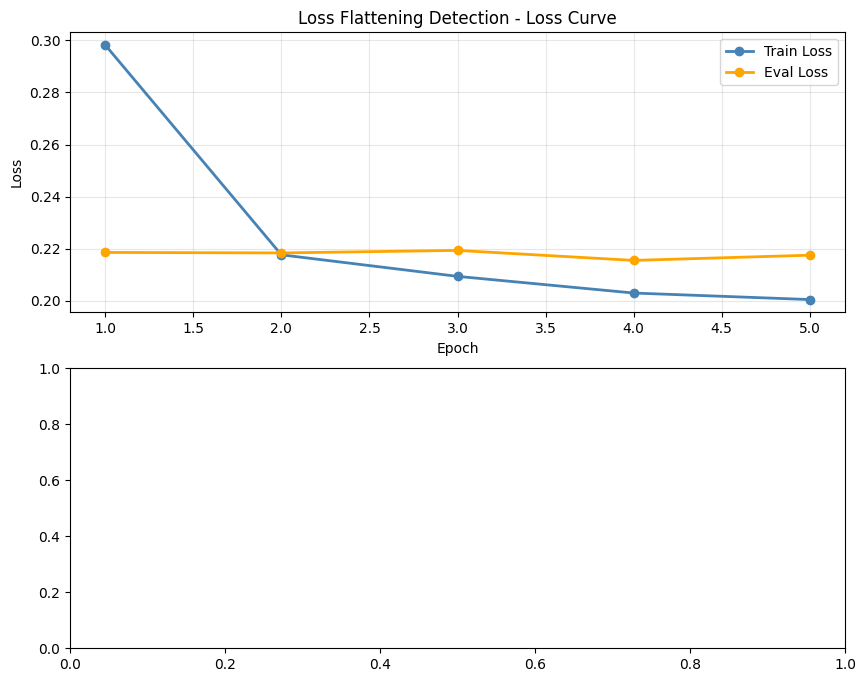


✗ Loss did not flatten within the training period (still improving)


In [5]:
plot_loss_flattening(train_losses, eval_losses, window_size=2)


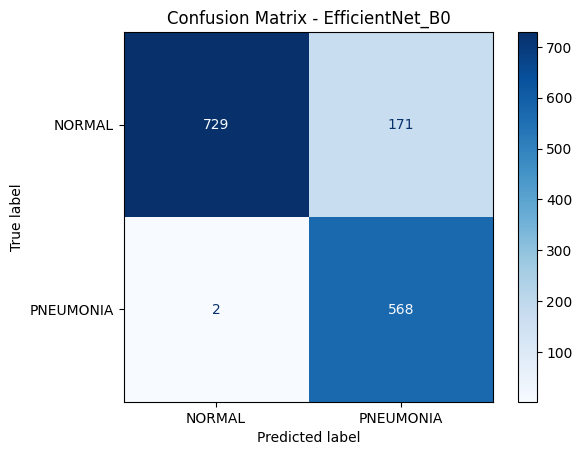

In [6]:

ConfusionMatrixDisplay.from_predictions(eval_labels, eval_preds.round(), display_labels=["NORMAL", "PNEUMONIA"], cmap="Blues")
plt.title("Confusion Matrix - EfficientNet_B0")
plt.show()